# Partial Differential Equations

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/block-hczhai/block2-preview/blob/master/docs/source/tutorial/dmrg-pde.ipynb)

In [1]:
!pip install block2==0.5.4rc10 -qq --progress-bar off --extra-index-url=https://block-hczhai.github.io/block2-preview/pypi/

## Prepration

In [2]:
import numpy as np
from pyblock2.algebra.io import MPSTools, MPOTools
from pyblock2.algebra.pde import PDETools1D

## Diffusion Equation (TD-DMRG)

In this example, we solve the following diffusion equation

$$\frac{\mathrm{d} f(x,t)}{\mathrm{d} t} = \nu \ \frac{\mathrm{d}^2 f(x,t)}{\mathrm{d} x^2}
+ \alpha\ g(x)$$

on the interval $x\in [-1,1]$ using the QTT grid with $2^8$ grid points along the $x$ direction. We propagate $nt = 50$ steps with the time step size $dt = 0.002$. $\nu = 0.1$.

**Kernels:** With ``kernel_a``, we have $\alpha = 0$, and with ``kernel_b``, we have $\alpha = 1$.

**Boundary condition and parameters:** $$ f(x,t=0) = \begin{cases}1 & -0.2\le x \le 0.2 \\ 0 & \text{otherwise}\end{cases} \\ g(x) = \begin{cases}1 & 0.3\le x \le 0.5 \\ 0 & \text{otherwise}\end{cases}$$

In [3]:
pde = PDETools1D(8, xi=-1, xf=1, bases=2)
pde.init_dmrg_driver(scratch="./tmp")
driver = pde.driver

nu = 0.1
dt = 0.002
nt = 50

sigma = nu * dt / pde.dx ** 2
print('sigma = ', sigma)

# H = nu * d^2/dx^2
pympo = pde.pympo_from_differential([0, 0, 1], pbc=True) * nu
mpo = MPOTools.to_block2(pympo, driver.basis, add_ident=True)

pyket = pde.pymps_from_range(-0.2, 0.2, 1.0)
ket = MPSTools.to_block2(pyket, driver.basis, tag='KET')
ket = driver.adjust_mps(ket, dot=2)[0]

pygket = pde.pymps_from_range(0.3, 0.5, 1.0)
gket = MPSTools.to_block2(pygket, driver.basis, tag='GKET')
gket = driver.adjust_mps(gket, dot=2)[0]

# df/dt = nu * d^2 f / dx^2
def kernel_a(beta, hop, a, b, xs):
    hop(a, b, beta) # b = beta * H * a

# df/dt = nu * d^2 f / dx^2 + g
def kernel_b(beta, hop, a, b, xs):
    hop(a, b, beta)
    b += beta * xs[0]

def run_td(mpo, ket, kernel, ext_mpss=None):
    tket = driver.copy_mps(ket, tag='TKET')
    for it in range(nt):
        if it % (nt // 4) == 0:
            print("it = %5d (%4.0f %%)" % (it, it * 100 / nt))
        tket = driver.td_dmrg(mpo, tket, -dt, -dt, final_mps_tag='TKET',
            n_sub_sweeps=2, te_type='rk4', kernel=kernel, ext_mpss=ext_mpss,
            cutoff=1E-24, hermitian=False, normalize_mps=False, bond_dims=[50], iprint=0)
    tket = driver.adjust_mps(tket, dot=1)[0]
    return MPSTools.from_block2(tket)

pytket_a = run_td(mpo, ket, kernel_a)
pytket_b = run_td(mpo, ket, kernel_b, [gket])

sigma =  3.2768
it =     0 (   0 %)
it =    12 (  24 %)
it =    24 (  48 %)
it =    36 (  72 %)
it =    48 (  96 %)
it =     0 (   0 %)
it =    12 (  24 %)
it =    24 (  48 %)
it =    36 (  72 %)
it =    48 (  96 %)


### Plot results

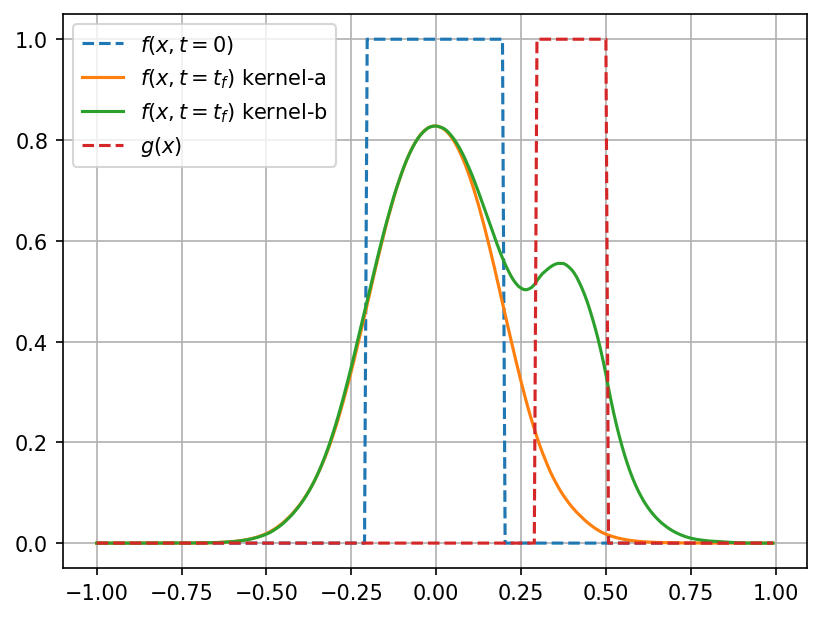

In [4]:
fx, fy = pde.pymps_rasterize(pyket)
gx, gy = pde.pymps_rasterize(pytket_a)
hx, hy = pde.pymps_rasterize(pytket_b)
jx, jy = pde.pymps_rasterize(pygket)

import matplotlib.pyplot as plt

plt.grid(which='both', axis='both')

plt.plot(fx, fy, '--', label='$f(x,t=0)$')
plt.plot(gx, gy, '-', label='$f(x,t=t_f)$ kernel-a')
plt.plot(hx, hy, '-', label='$f(x,t=t_f)$ kernel-b')
plt.plot(jx, jy, '--', label='$g(x)$')
plt.legend(loc='upper left')
plt.gcf().set_dpi(150)
plt.show()

## Time-Independent Schrödinger Equation (Ground and Excited State DMRG)

In this example, we solve the following time-independent schrödinger equation

$$ \left( -\frac{\hbar^2}{2\mu} \frac{\mathrm{d}^2}{\mathrm{d} x^2}+V(x) \right) \psi(x) = E\ \psi(x) $$

on the interval $x\in[-2,7]$ using the QTT grid with $2^{12}$ grid points along the $x$ direction. We use the Morse potential
$$V(x) = D_e \big(\mathrm{e}^{-2\beta x} - 2\mathrm{e}^{-\beta x} \big)$$

The analytical solution is given by
$$E_n = -D_e + \left( n+\frac{1}{2}\right) \hbar\omega -  \left( n+\frac{1}{2}\right)^2 \frac{\hbar^2\omega^2}{4D_e},\quad\left(\omega = \sqrt{\frac{2D_e\beta^2}{\mu}}\right)$$

**Parameters:** $\beta = 0.5, \mu=6, D_e=12, \hbar=1$.

In [5]:
pde = PDETools1D(12, xi=-2, xf=7, bases=2)
pde.init_dmrg_driver(scratch="./tmp")
driver = pde.driver

beta = 0.5
mu = 6
de = 12

# V(x) = de * exp(-2 beta x) - 2 * exp(-beta x)
pymps = de * (pde.pymps_from_exponential(np.e, -2 * beta) - 2 * pde.pymps_from_exponential(np.e, -beta))

# H = (-1/2mu) * d^2/dx^2 + V(x)
pympo = (-1 / (2 * mu)) * pde.pympo_from_differential([0, 0, 1], pbc=True) + pymps.diag()

mpo = MPOTools.to_block2(pympo, driver.basis, add_ident=True)

nroots = 3
kets = [driver.get_random_mps(tag="KET%d" % x, bond_dim=1) for x in range(nroots)]
energies = []
for ir in range(nroots):
    energy = driver.dmrg(mpo, kets[ir], n_sweeps=12, bond_dims=[50] * 12,
        noises=[0] * 12, thrds=[0] * 12, dav_max_iter=500, iprint=1,
        proj_mpss=kets[:ir], proj_weights=[10.0] * ir,
        dav_rel_conv_thrd=1E-5, tol=1E-8, cutoff=1E-30)
    energies.append(energy)

omega = (2 * de * beta ** 2 / mu) ** 0.5
exact = [-de + (n + 0.5) * omega - (n + 0.5) ** 2 * omega ** 2 / (4 * de) for n in range(nroots)]

for ir in range(nroots):
    print("E[%2d] = %15.8f Error = %9.2e" % (ir, energies[ir], energies[ir] - exact[ir]))

pykets = []
for ir in range(nroots):
    kets[ir] = driver.adjust_mps(kets[ir], dot=1)[0]
    pykets.append(MPSTools.from_block2(kets[ir]))


Sweep =    0 | Direction =  forward | Bond dimension =   50 | Noise =  0.00e+00 | Dav threshold =  0.00e+00
Time elapsed =      0.018 | E =      -7.0114287425 | DW = 0.00000e+00

Sweep =    1 | Direction = backward | Bond dimension =   50 | Noise =  0.00e+00 | Dav threshold =  0.00e+00
Time elapsed =      0.185 | E =     -11.5051563140 | DE = -4.49e+00 | DW = 1.57547e-30

Sweep =    2 | Direction =  forward | Bond dimension =   50 | Noise =  0.00e+00 | Dav threshold =  0.00e+00
Time elapsed =      0.244 | E =     -11.5052092135 | DE = -5.29e-05 | DW = 4.76125e-31

Sweep =    3 | Direction = backward | Bond dimension =   50 | Noise =  0.00e+00 | Dav threshold =  0.00e+00
Time elapsed =      0.290 | E =     -11.5052092135 | DE = 3.59e-13 | DW = 3.16122e-31


Sweep =    0 | Direction =  forward | Bond dimension =   50 | Noise =  0.00e+00 | Dav threshold =  0.00e+00
Time elapsed =      0.031 | E =      -6.6026598014 | DW = 0.00000e+00

Sweep =    1 | Direction = backward | Bond dimension 

### Plot results

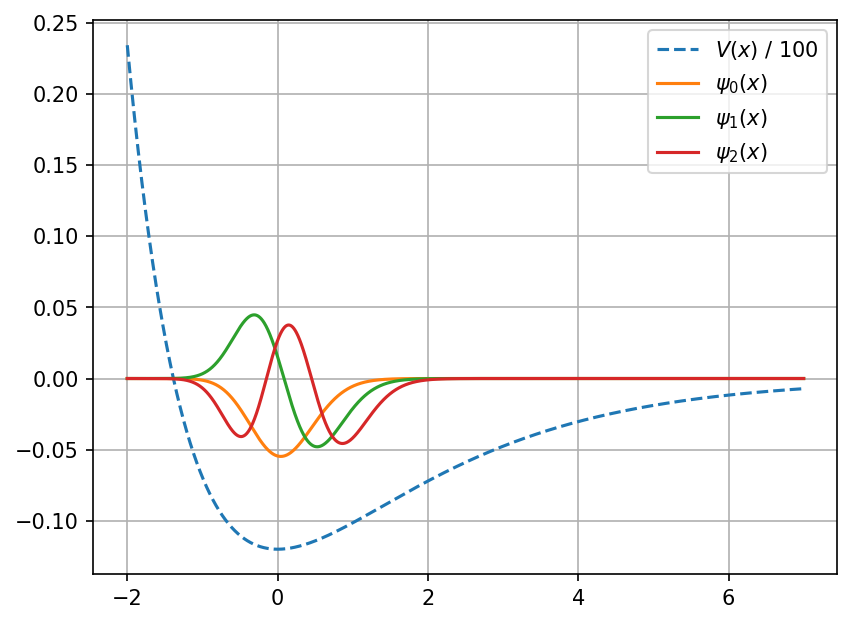

In [6]:
import matplotlib.pyplot as plt

plt.grid(which='both', axis='both')

fx, fy = pde.pymps_rasterize(pymps / 100)
plt.plot(fx, fy, '--', label='$V(x)$ / 100')

for ir, pyket in enumerate(pykets):
    fx, fy = pde.pymps_rasterize(pyket)
    plt.plot(fx, fy, '-', label='$\\psi_%d(x)$' % ir)
plt.legend(loc='upper right')
plt.gcf().set_dpi(150)
plt.show()

## Poisson Equation (Dynamical DMRG)

In this example, we solve the following Poisson equation

$$ \frac{\mathrm{d}^2}{\mathrm{d}x^2}\ f(x) = g(x) $$

on the interval $x\in [0,1]$ (periodic) using the QTT grid with $2^8$ grid points along the $x$ direction. We set

$$g(x) = \delta(x - 0.35) + \delta(x - 0.60) $$

and $f(x=0) = f(x=1) = 0$ as the boundary condition.

In [7]:
pde = PDETools1D(8, xi=0, xf=1, bases=2)
pde.init_dmrg_driver(scratch="./tmp")
driver = pde.driver

# H = d^2/dx^2
pympo = pde.pympo_from_differential([0, 0, 1], pbc=True)
mpo = MPOTools.to_block2(pympo, driver.basis, add_ident=True)

# g(x) = delta(x - 0.35) + delta(x - 0.60)
pyket = pde.pymps_from_range(0.3, 0.3, 1.0) + pde.pymps_from_range(0.60, 0.60, 1.0)
ket = MPSTools.to_block2(pyket, driver.basis, tag='KET')
ket = driver.adjust_mps(ket, dot=2)[0]

# p(x) = delta(x - 0.0) (boundary condition)
pypket = pde.pymps_from_range(0.0, 0.0, 1.0)
pket = MPSTools.to_block2(pypket, driver.basis, tag='PKET')
pket = driver.adjust_mps(pket, dot=2)[0]

impo = driver.get_identity_mpo()

bra = driver.get_random_mps(tag="BRA", bond_dim=5, nroots=1)

# solve d^2 f(x) /dx^2 = g(x) with boundary condition f(0) = 0
driver.multiply(bra, impo, ket, n_sweeps=12, bond_dims=[50] * 12,
    noises=[0] * 12, thrds=[0] * 12, tol=0.0, left_mpo=mpo,
    linear_max_iter=500, linear_rel_conv_thrd=1E-5, cutoff=1E-24, solver_type='CG',
    proj_mpss=[pket], proj_weights=[1.0], proj_bond_dim=100,
    iprint=1)

bra = driver.adjust_mps(bra, dot=1)[0]
pybra = MPSTools.from_block2(bra)


Sweep =    0 | Direction =  forward | BRA bond dimension =    5 | Noise =  0.00e+00 | Linear threshold =  0.00e+00
Time elapsed =      0.024 | F =  -1.1776266e-04 | DW = 1.82162e-25

Sweep =    1 | Direction = backward | BRA bond dimension =    5 | Noise =  0.00e+00 | Linear threshold =  0.00e+00
Time elapsed =      0.055 | F =   -0.0026878715 | DF = -2.57e-03 | DW = 6.78374e-22

Sweep =    2 | Direction =  forward | BRA bond dimension =    5 | Noise =  0.00e+00 | Linear threshold =  0.00e+00
Time elapsed =      0.083 | F =   -0.0026878715 | DF = -1.15e-14 | DW = 9.16664e-25

Sweep =    3 | Direction = backward | BRA bond dimension =    5 | Noise =  0.00e+00 | Linear threshold =  0.00e+00
Time elapsed =      0.106 | F =   -0.0026878715 | DF = 2.80e-13 | DW = 1.32988e-22

Sweep =    4 | Direction =  forward | BRA bond dimension =    5 | Noise =  0.00e+00 | Linear threshold =  0.00e+00
Time elapsed =      0.129 | F =   -0.0026878715 | DF = -3.50e-15 | DW = 6.72943e-25

Sweep =    5 | Di

### Plot results

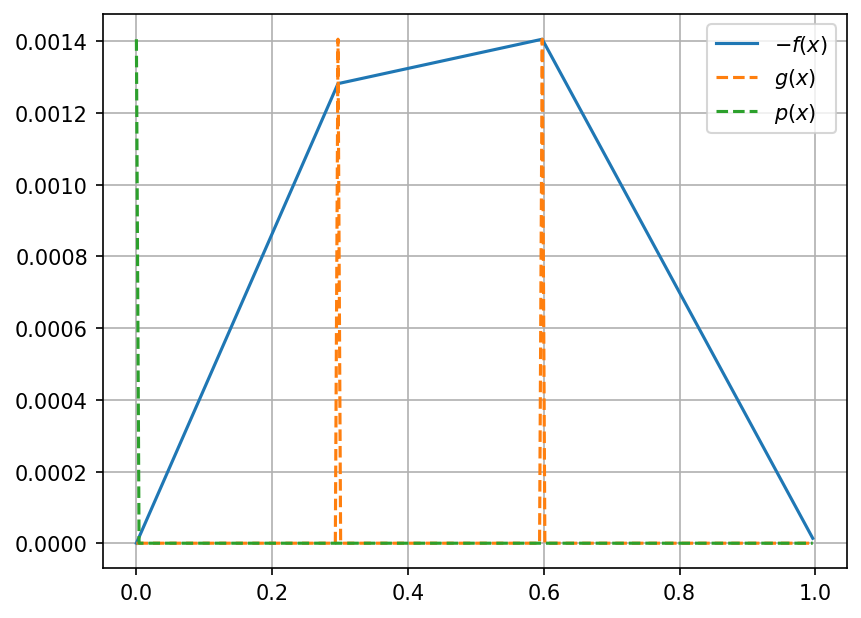

In [8]:
import matplotlib.pyplot as plt

plt.grid(which='both', axis='both')

fx, fy = pde.pymps_rasterize(pybra)
gx, gy = pde.pymps_rasterize(pyket)
px, py = pde.pymps_rasterize(pypket)
plt.plot(fx, -fy, '-', label='$-f(x)$')
plt.plot(gx, gy * max(abs(fy)), '--', label='$g(x)$')
plt.plot(px, py * max(abs(fy)), '--', label='$p(x)$')

plt.legend(loc='upper right')
plt.gcf().set_dpi(150)
plt.show()